In [1]:
# Netflix Data Cleaning, Analysis & Visualization

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Step 2: Load Dataset
data = pd.read_csv("/content/netflix_titles.csv")

# Step 3: Initial Exploration
print(data.shape)
print(data.info())
print(data.isnull().sum())


(8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
descr

In [2]:
# Step 4: Data Cleaning
# Drop duplicates
data.drop_duplicates(inplace=True)

# Drop rows with missing critical values
data.dropna(subset=['director', 'cast', 'country'], inplace=True)

# Convert 'date_added' to datetime
data['date_added'] = pd.to_datetime(data['date_added'], errors='coerce')

# Extract year, month, and day from date_added
data['year'] = data['date_added'].dt.year
data['month'] = data['date_added'].dt.month
data['day'] = data['date_added'].dt.day
data.describe()



,date_added,release_year,year,month,day
count,5332,5336.000000,5332.000000,5332.000000,5332.000000
mean,2019-04-28 10:45:27.681920512,2012.743253,2018.825019,6.620405,11.865904
min,2008-01-01 00:00:00,1942.000000,2008.000000,1.000000,1.000000
25%,2018-04-06 00:00:00,2011.000000,2018.000000,4.000000,1.000000
50%,2019-06-16 00:00:00,2016.000000,2019.000000,7.000000,11.000000
75%,2020-06-26 06:00:00,2018.000000,2020.000000,10.000000,20.000000
max,2021-09-24 00:00:00,2021.000000,2021.000000,12.000000,31.000000
std,NaN,9.622570,1.541384,3.495521,9.928001


/tmp/ipython-input-3-897523356.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='type', palette='Set2')


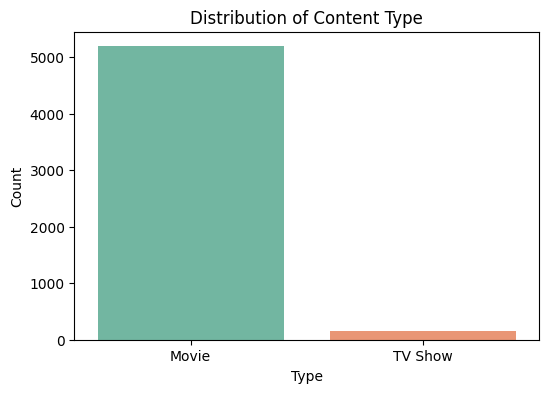

/tmp/ipython-input-3-897523356.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='Set3')


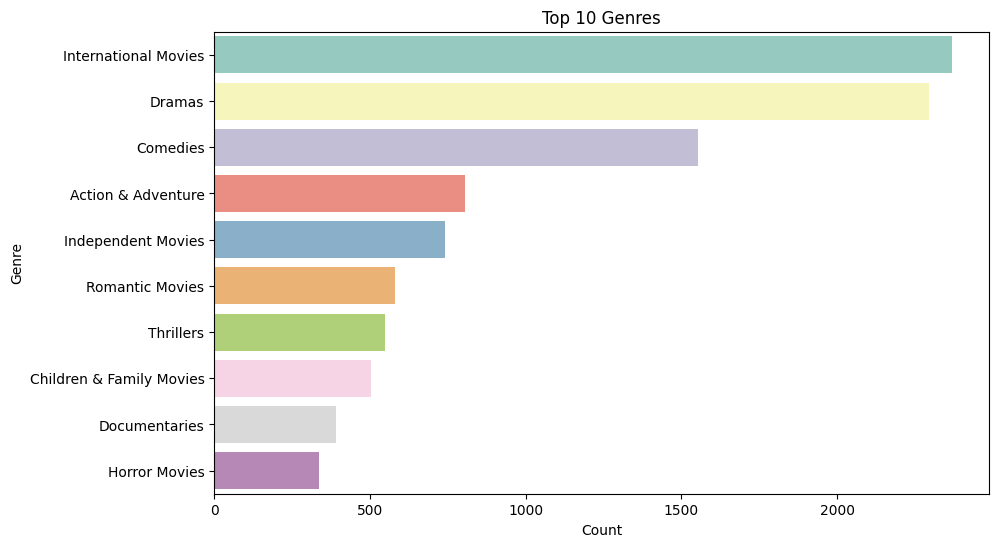

/tmp/ipython-input-3-897523356.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='year', data=data, palette='coolwarm')


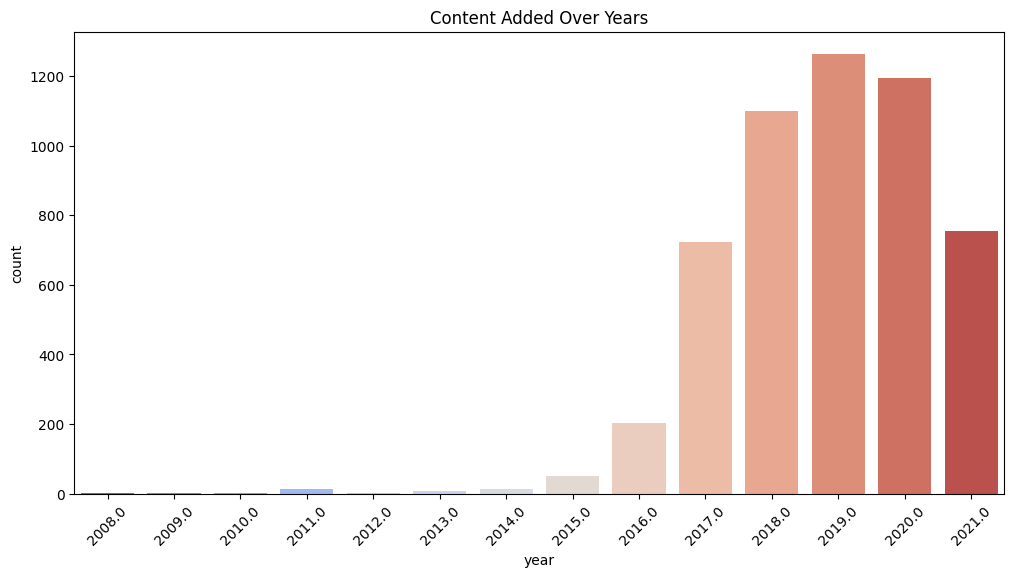

/tmp/ipython-input-3-897523356.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, y='rating', order=data['rating'].value_counts().index[:10], palette='viridis')


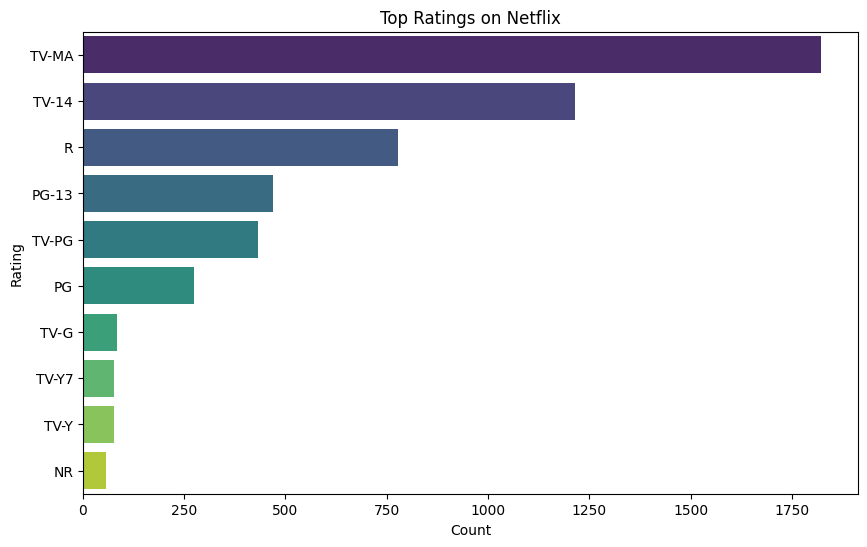

/tmp/ipython-input-3-897523356.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='cool')


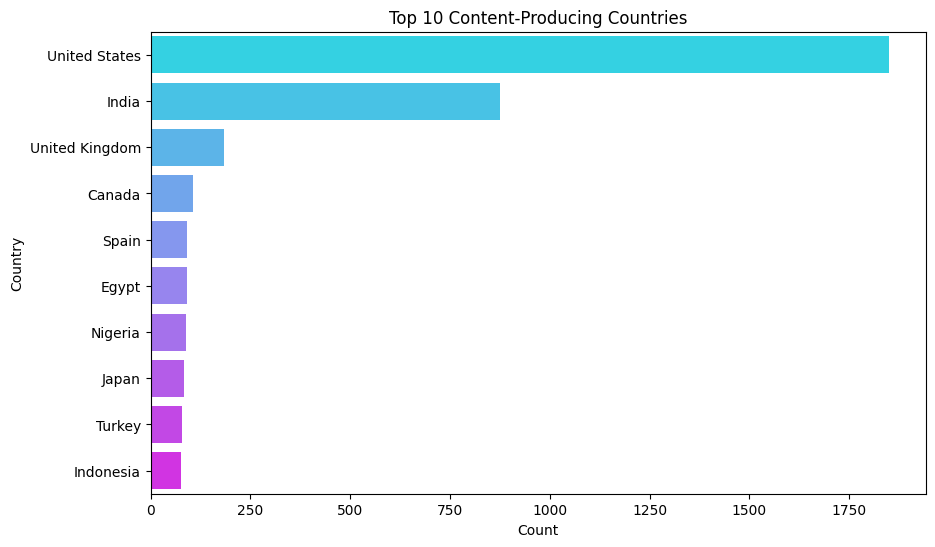

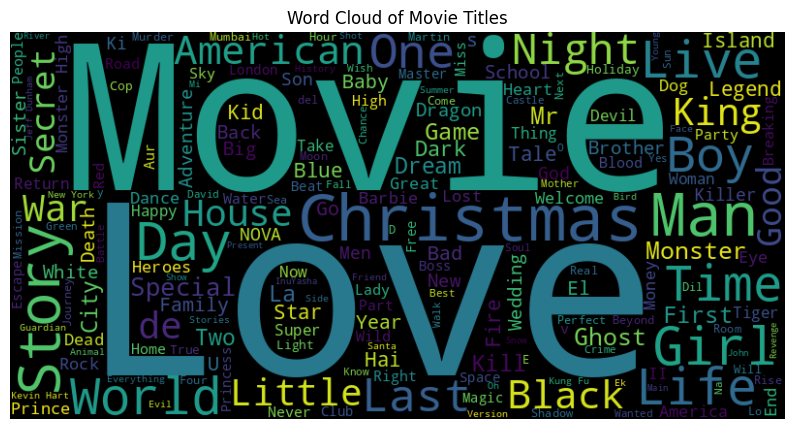


--- Conclusion ---
1. Movies dominate the content library compared to TV Shows.
2. Top genres include International Movies, Dramas, and Comedies.
3. Content production peaked around 2019-2020.
4. US and India are major contributors.
5. Ratings like TV-MA and TV-14 are most frequent.


In [3]:
# Step 5: EDA (Exploratory Data Analysis)

# Content Type Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='type', palette='Set2')
plt.title('Distribution of Content Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

# Most Common Genres
data['genres'] = data['listed_in'].apply(lambda x: x.split(", "))
genres_flat = sum(data['genres'], [])
genre_counts = pd.Series(genres_flat).value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='Set3')
plt.title('Top 10 Genres')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

# Content Added Over Years
plt.figure(figsize=(12,6))
sns.countplot(x='year', data=data, palette='coolwarm')
plt.title('Content Added Over Years')
plt.xticks(rotation=45)
plt.show()

# Rating Distribution
plt.figure(figsize=(10,6))
sns.countplot(data=data, y='rating', order=data['rating'].value_counts().index[:10], palette='viridis')
plt.title('Top Ratings on Netflix')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.show()

# Top 10 Countries
top_countries = data['country'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='cool')
plt.title('Top 10 Content-Producing Countries')
plt.xlabel('Count')
plt.ylabel('Country')
plt.show()

# WordCloud for Movie Titles
movie_titles = data[data['type'] == 'Movie']['title']
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(' '.join(movie_titles))
plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Movie Titles')
plt.show()

# Step 6: Conclusion
print("\n--- Conclusion ---")
print("1. Movies dominate the content library compared to TV Shows.")
print("2. Top genres include International Movies, Dramas, and Comedies.")
print("3. Content production peaked around 2019-2020.")
print("4. US and India are major contributors.")
print("5. Ratings like TV-MA and TV-14 are most frequent.")


In [4]:
data.describe()


,date_added,release_year,year,month,day
count,5332,5336.000000,5332.000000,5332.000000,5332.000000
mean,2019-04-28 10:45:27.681920512,2012.743253,2018.825019,6.620405,11.865904
min,2008-01-01 00:00:00,1942.000000,2008.000000,1.000000,1.000000
25%,2018-04-06 00:00:00,2011.000000,2018.000000,4.000000,1.000000
50%,2019-06-16 00:00:00,2016.000000,2019.000000,7.000000,11.000000
75%,2020-06-26 06:00:00,2018.000000,2020.000000,10.000000,20.000000
max,2021-09-24 00:00:00,2021.000000,2021.000000,12.000000,31.000000
std,NaN,9.622570,1.541384,3.495521,9.928001
